In [1]:
# ! pip install astroML

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math as mt
from astroML.datasets import fetch_dr7_quasar
from scipy.interpolate import interp1d

In [3]:
data = fetch_dr7_quasar()

In [4]:
data = data[:10000]
z = data['redshift']

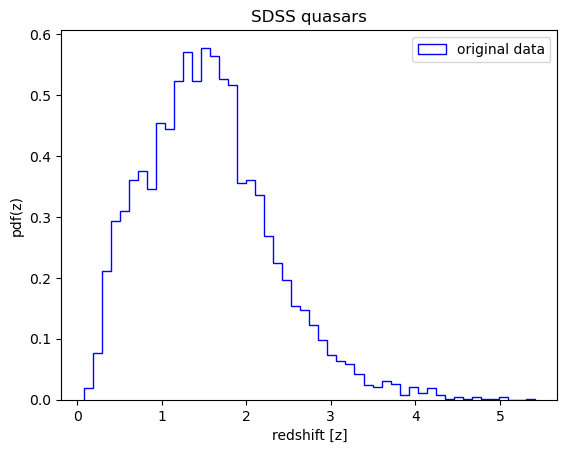

In [5]:
# let's look at the redshift distribution of the quasars in the Sloan Digital Sky Survey
entries, raw_bin_edges, _ = plt.hist(z, bins=50, edgecolor='blue', histtype='step', label='original data', density=True)
plt.title("SDSS quasars")
plt.xlabel("redshift [z]")
plt.ylabel("pdf(z)")
plt.legend()
plt.show()
plt.close()

In [6]:
# let's use the rejection sampling technique
bin_edges = np.resize(raw_bin_edges, raw_bin_edges.size-1)
N = 100000
ymax = np.max(entries)
xmin = np.min(bin_edges)
xmax = np.max(bin_edges)
x = np.random.uniform(xmin,xmax,N)
y = np.random.uniform(0,ymax,N)
sel_z = []
for i in range(len(x)):
    for j in range(len(bin_edges)):
        if(x[i]>=bin_edges[j] and x[i]<bin_edges[j+1]):
            if(y[i]<=entries[j]): 
                sel_z.append(x[i])
if len(sel_z) > 10000:
    sel_z = sel_z[:10000]

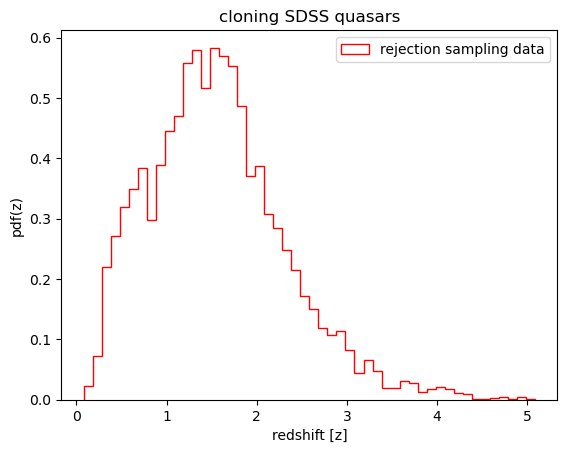

In [7]:
plt.hist(sel_z, bins=50, edgecolor='red', label='rejection sampling data', histtype='step', density=True)
plt.title("cloning SDSS quasars")
plt.xlabel("redshift [z]")
plt.ylabel("pdf(z)")
plt.legend()
plt.show()
plt.close()

In [8]:
# let's use the inverse transform sampling technique
CDF = np.cumsum(entries)/np.sum(entries)
bin_centers = (raw_bin_edges[:-1] + raw_bin_edges[1:])/2
inverse_CDF = interp1d(CDF, bin_centers)
P = np.random.uniform(np.min(CDF), np.max(CDF), 10000)
z_inverse = inverse_CDF(P)

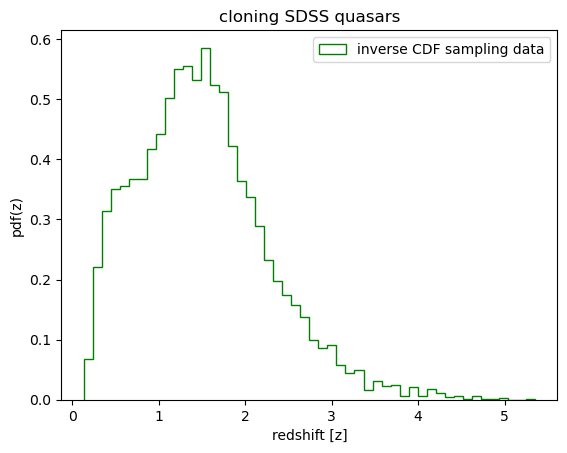

In [9]:
plt.hist(z_inverse, bins=50, edgecolor='green', label='inverse CDF sampling data', histtype='step', density=True)
plt.title("cloning SDSS quasars")
plt.xlabel("redshift [z]")
plt.ylabel("pdf(z)")
plt.legend()
plt.show()
plt.close()

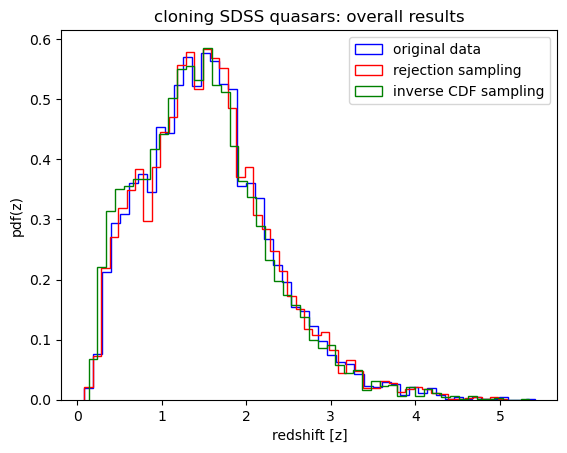

In [10]:
plt.hist(z, bins=50, edgecolor='blue', label='original data', histtype='step', density=True)
plt.hist(sel_z, bins=50, edgecolor='red', label='rejection sampling', histtype='step', density=True)
plt.hist(z_inverse, bins=50, edgecolor='green', label='inverse CDF sampling', histtype='step', density=True)
plt.title("cloning SDSS quasars: overall results")
plt.xlabel("redshift [z]")
plt.ylabel("pdf(z)")
plt.legend()
plt.show()
plt.close()

In [11]:
print(len(z), len(sel_z), len(z_inverse))

10000 10000 10000
